<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Ridge%20Regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      GENERATED MALL CUSTOMER DATASET

First 10 Rows:
   Age  Annual_Income  Purchases  Average_Purchase  Website_Visits  \
0   56             16         10            342.76              25   
1   69            143         16            396.69               6   
2   46             62          8            254.24              27   
3   32             51          6             52.59               8   
4   60             23         12            273.18               2   
5   25            113         24            297.55              12   
6   38             62         28            375.27              13   
7   56            145         21            221.51              25   
8   36             68          8             72.51              21   
9   40            134         26            149.05               7   

   Loyalty_Years  Spending_Score  
0           14.0       65.845795  
1           14.9       92.260105  
2            3.0       63.742146  
3            6.2       37.445987  


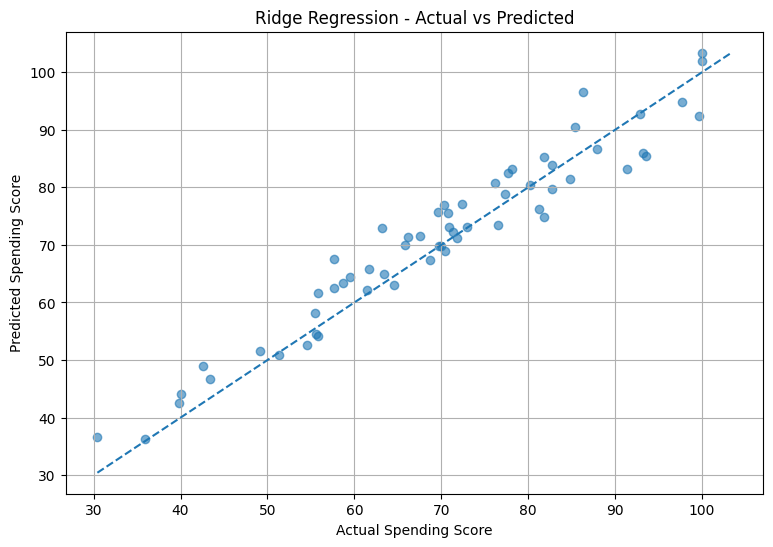

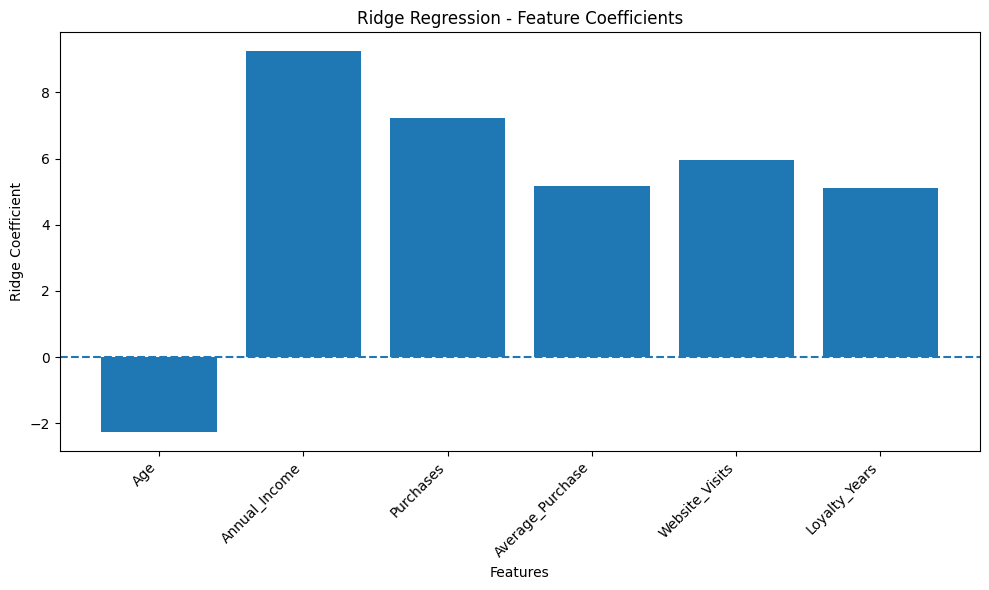

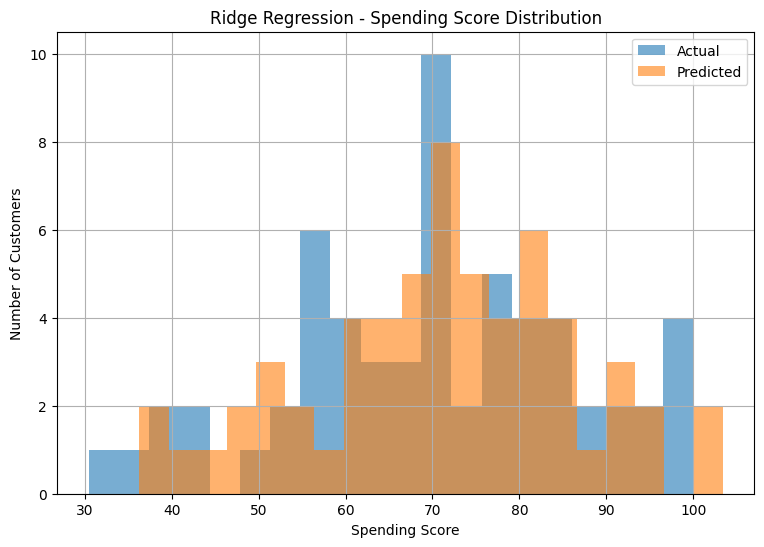


           FINAL RESULT
Ridge R² Score = 0.9243
Ridge R² Percentage = 92.43%
Ridge RMSE = 4.5423

Graphs Generated:
1. Actual vs Predicted
2. Feature Coefficients
3. Actual vs Predicted Distribution


In [17]:
# ============================================================
# RIDGE REGRESSION - MALL CUSTOMERS DATASET
# DATASET GENERATED INSIDE THE CODE
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# ------------------------------------------------------------
# 2. GENERATE MALL CUSTOMERS DATASET
# ------------------------------------------------------------

np.random.seed(42)

n = 300

# Customer Age
age = np.random.randint(
    18,
    71,
    n
)

# Annual Income in thousands
annual_income = np.random.randint(
    15,
    151,
    n
)

# Number of purchases per year
purchases = np.random.randint(
    1,
    31,
    n
)

# Average purchase amount
avg_purchase = np.round(
    np.random.uniform(
        10,
        500,
        n
    ),
    2
)

# Website visits per month
website_visits = np.random.randint(
    1,
    31,
    n
)

# Loyalty years
loyalty_years = np.round(
    np.random.uniform(
        0.5,
        15,
        n
    ),
    1
)


# ------------------------------------------------------------
# 3. GENERATE SPENDING SCORE
# ------------------------------------------------------------

spending_score = (
    10
    + 0.25 * annual_income
    + 0.8 * purchases
    + 0.04 * avg_purchase
    + 0.7 * website_visits
    + 1.2 * loyalty_years
    - 0.15 * age
)


# Add random noise
spending_score += np.random.normal(
    0,
    5,
    n
)


# Keep score between 1 and 100
spending_score = np.clip(
    spending_score,
    1,
    100
)


# ------------------------------------------------------------
# 4. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({

    "Age": age,

    "Annual_Income": annual_income,

    "Purchases": purchases,

    "Average_Purchase": avg_purchase,

    "Website_Visits": website_visits,

    "Loyalty_Years": loyalty_years,

    "Spending_Score": spending_score

})


# ------------------------------------------------------------
# 5. DISPLAY DATASET
# ------------------------------------------------------------

print("======================================")
print("      GENERATED MALL CUSTOMER DATASET")
print("======================================")

print("\nFirst 10 Rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    "Spending_Score",
    axis=1
)

y = df["Spending_Score"]


# ------------------------------------------------------------
# 7. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)


print("\nTraining Data:", X_train.shape)

print(
    "Testing Data:",
    X_test.shape
)


# ------------------------------------------------------------
# 8. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ------------------------------------------------------------
# 9. CREATE RIDGE REGRESSION MODEL
# ------------------------------------------------------------

model = Ridge(
    alpha=1.0
)


# ------------------------------------------------------------
# 10. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 11. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 12. CALCULATE R² SCORE
# ------------------------------------------------------------

r2 = r2_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# 13. CALCULATE RMSE
# ------------------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


# ------------------------------------------------------------
# 14. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n======================================")
print("         RIDGE REGRESSION RESULTS")
print("======================================")

print(
    f"R² Score = {r2:.4f}"
)

print(
    f"R² Score Percentage = "
    f"{r2 * 100:.2f}%"
)

print(
    f"RMSE = {rmse:.4f}"
)


# ------------------------------------------------------------
# 15. RIDGE COEFFICIENTS
# ------------------------------------------------------------

print("\nRidge Coefficients:")

coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

print(
    coefficients
)


# ============================================================
# GRAPH 1 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)


# Perfect prediction line

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    linestyle="--"
)


plt.xlabel(
    "Actual Spending Score"
)

plt.ylabel(
    "Predicted Spending Score"
)

plt.title(
    "Ridge Regression - Actual vs Predicted"
)

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2 - FEATURE COEFFICIENTS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Ridge Coefficient"
)

plt.title(
    "Ridge Regression - Feature Coefficients"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3 - ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    y_test,
    bins=20,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    y_pred,
    bins=20,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel(
    "Spending Score"
)

plt.ylabel(
    "Number of Customers"
)

plt.title(
    "Ridge Regression - Spending Score Distribution"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"Ridge R² Score = {r2:.4f}"
)

print(
    f"Ridge R² Percentage = "
    f"{r2 * 100:.2f}%"
)

print(
    f"Ridge RMSE = {rmse:.4f}"
)

print("\nGraphs Generated:")

print(
    "1. Actual vs Predicted"
)

print(
    "2. Feature Coefficients"
)

print(
    "3. Actual vs Predicted Distribution"
)